### Invariant of neural representation

- build multivariate gaussian distribution with covariance matrix
- The covariance matrix is built by rotating the original covariance matrix
- The rotation is done by a design matrix B.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

# --- helpers (same as before) ---
def rotation_matrix_2d(phi_rad: float) -> np.ndarray:
    c, s = np.cos(phi_rad), np.sin(phi_rad)
    return np.array([[c, -s],
                     [s,  c]])

def rotate_cov_2d(Sigma: np.ndarray, phi_rad: float) -> np.ndarray:
    R = rotation_matrix_2d(phi_rad)
    Srot = R @ Sigma @ R.T
    return 0.5 * (Srot + Srot.T)

def eig_sorted(Sigma: np.ndarray):
    w, V = np.linalg.eigh(Sigma)
    idx = np.argsort(w)[::-1]
    return w[idx], V[:, idx]

def ellipse_xy_from_cov(Sigma: np.ndarray, n_std: float = 2.0, num: int = 400):
    w, V = eig_sorted(Sigma)
    radii = n_std * np.sqrt(np.maximum(w, 0))
    t = np.linspace(0, 2*np.pi, num)
    circle = np.vstack([np.cos(t), np.sin(t)])  # 2 x num
    E = V @ np.diag(radii) @ circle
    return E[0], E[1]

def _plot_eigenvectors(ax, Sigma, color, label_prefix, alpha=0.95):
    """
    Plot BOTH eigenvectors (columns of V) scaled to 1σ (sqrt eigenvalues).
    Solid line = eigvec 1 (largest λ), dashed line = eigvec 2.
    Returns two Line2D proxy artists for the legend.
    """
    w, V = eig_sorted(Sigma)
    styles = ["-", "--"]
    labels = [f"{label_prefix} eigvec1 (λ₁)", f"{label_prefix} eigvec2 (λ₂)"]
    proxies = []
    for i in range(2):
        v = V[:, i] * np.sqrt(w[i])  # length = 1σ along that axis
        ax.plot([0, v[0]], [0, v[1]], styles[i], linewidth=2.2, color=color, alpha=alpha)
        # add a faint opposite direction to hint at axis line (optional)
        ax.plot([0, -v[0]], [0, -v[1]], styles[i], linewidth=1.2, color=color, alpha=0.35)
        # proxy for legend (so we can style the legend line exactly)
        proxies.append(Line2D([0], [0], linestyle=styles[i], color=color, lw=2.2, label=labels[i]))
    return proxies


def instantiate_before_after_X(Sigma, Sigma_rot, seed: int = 0, n_samples: int = 600):
    rng = np.random.default_rng(seed)
    X_before = rng.multivariate_normal([0, 0], Sigma, size=n_samples)
    X_after  = rng.multivariate_normal([0, 0], Sigma_rot, size=n_samples)
    return X_before, X_after

# --- one-figure comparison with BOTH eigenvectors ---
def plot_2D_before_after_distribution(Sigma, Sigma_rot, phi_deg: float, seed: int = 0,
                                       n_samples: int = 600, show_samples: bool = True):
    global X_before, X_after
    X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, seed=seed, n_samples=n_samples)

    ex1, ey1 = ellipse_xy_from_cov(Sigma, n_std=2.0)
    ex2, ey2 = ellipse_xy_from_cov(Sigma_rot, n_std=2.0)

    fig, ax = plt.subplots(figsize=(7, 6))

    # scatter samples (optional)
    if show_samples:
        ax.scatter(X_before[:,0], X_before[:,1], s=8, alpha=0.25, color="tab:blue",  label="samples (before)")
        ax.scatter(X_after[:,0],  X_after[:,1],  s=8, alpha=0.25, color="tab:orange", label="samples (after)")

    # 2σ ellipses
    l1, = ax.plot(ex1, ey1, lw=2.2, color="tab:blue",  label="ellipse 2σ (before)")
    l2, = ax.plot(ex2, ey2, lw=2.2, color="tab:orange", label=f"ellipse 2σ (after, φ={phi_deg}°)")

    # BOTH eigenvectors for each covariance
    proxies_b = _plot_eigenvectors(ax, Sigma,     color="tab:blue",  label_prefix="before")
    proxies_a = _plot_eigenvectors(ax, Sigma_rot, color="tab:orange", label_prefix="after")

    # assemble legend
    legend_items = []
    if show_samples:
        legend_items += [Line2D([0],[0], marker='o', linestyle='None', color="tab:blue",  alpha=0.25, label="samples (before)"),
                         Line2D([0],[0], marker='o', linestyle='None', color="tab:orange", alpha=0.25, label="samples (after)")]
    legend_items += [l1, l2] + proxies_b + proxies_a
    ax.legend(handles=legend_items, loc="best")

    ax.set_aspect("equal", adjustable="box")
    ax.set_title("Before vs After rotation — both eigenvectors per covariance")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    fig.tight_layout()
    plt.show()




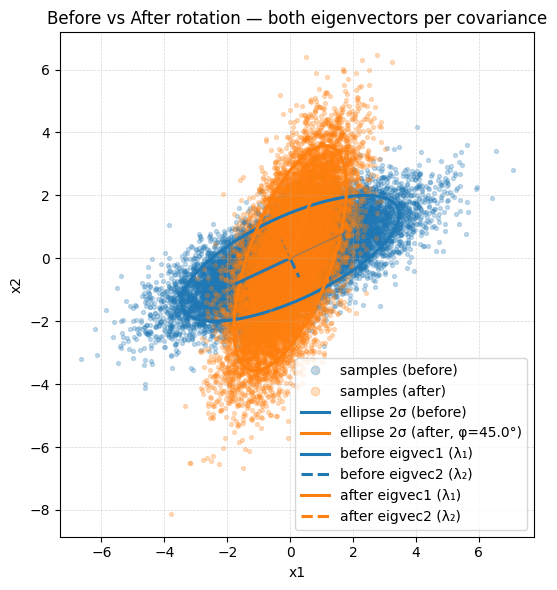

In [9]:
d = 2
m = 2
phi_deg = 45.0
n_samples = 15000
X_seed = 0
# get /sigma
Sigma = np.array([[3.0, 1.2],
                    [1.2, 1.0]])
Sigma_rot = rotate_cov_2d(Sigma, np.deg2rad(phi_deg))

# visualize the before and after covariances with both eigenvectors
plot_2D_before_after_distribution(Sigma, Sigma_rot, phi_deg, n_samples=n_samples, seed=X_seed)

### Apply Leen's complete model to before and after drifted models

In [3]:
from leen_models import LeenCompletePCA
from leen_models import Y_aligned_training_testing, Y_aligned_training_testing_online

In [10]:
def run_experiment(model, data, m, runs = 10, graph = False):
    df_best_corr = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])
    
    for run in range(runs):
        # model = LeenCompletePCA(d, m, eta_w=1e-6, eta_q=1e-2, C=2.0,
        #                   ema_alpha=0.1, symmetrize_q=True, seed=None, settling_steps=10, noise_level=0.01)
        order, similarity = Y_aligned_training_testing_online(model, data, batch_size=1, alignment = "corr")
        # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr.iloc[run, :] = ordered_similarity
        print(f"run {run+1:2d} | order = {order} | best|corr|= {np.round(similarity,3)}")

    if graph == True:
        # plot the bar graph with error bars of mean and std based on df_best_corr
        means = df_best_corr.mean(axis=0)
        stds = df_best_corr.std(axis=0)
        plt.figure(figsize=(10, 6))
        plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
        # plt.ylim(0, 1.1)
        plt.ylabel('Mean Absolute Correlation')
        plt.title('Mean Absolute Correlation with True PCs Across Runs')
        plt.show()
    return df_best_corr

In [ ]:
# runs = 10
model_paras = dict(
    input_dim=2, output_dim=2,
    eta_w=5e-5,          # base
    eta_q=2e-3,          # ~4x eta_w
    C=2.0,
    ema_alpha=0.03,
    symmetrize_q=True,
    seed=None,
    noise_level=0.001,
    settling_steps=10
)


model_paras_after = dict(
    eta_w=1e-3,
    eta_q=3e-3
)

### Single run

In [6]:
# leen_model = LeenCompletePCA(**model_paras)

# run_experiment(leen_model, X_before, m=m, runs=1)

In [7]:
# leen_model.eta_w = 1e-3  # to 2e-3 if the spectral gap is small
# leen_model.eta_q = 3e-3  # keep >= eta_w; up to 5e-3 if columns start to couple

# run_experiment(leen_model, X_after, m=m, runs=1)

### Multiple runs

run  1
X_before
step    0 | order = [1 0] | best|corr|= [0.644 0.999]
step 1000 | order = [1 0] | best|corr|= [0.839 0.96 ]
step 2000 | order = [1 0] | best|corr|= [0.885 0.975]
step 3000 | order = [1 0] | best|corr|= [0.853 0.979]
step 4000 | order = [1 0] | best|corr|= [0.959 0.99 ]
step 5000 | order = [1 0] | best|corr|= [0.928 0.991]
step 6000 | order = [1 0] | best|corr|= [0.993 0.996]
step 7000 | order = [1 0] | best|corr|= [0.986 0.996]
step 8000 | order = [1 0] | best|corr|= [0.97  0.996]
step 9000 | order = [1 0] | best|corr|= [0.997 0.998]
step 10000 | order = [1 0] | best|corr|= [0.964 0.997]
step 11000 | order = [1 0] | best|corr|= [0.997 0.999]
step 12000 | order = [1 0] | best|corr|= [0.988 0.999]
step 13000 | order = [1 0] | best|corr|= [1. 1.]
step 14000 | order = [1 0] | best|corr|= [0.984 0.999]
X_after
step    0 | order = [0 1] | best|corr|= [0.953 0.347]
step 1000 | order = [1 0] | best|corr|= [0.972 0.282]
step 2000 | order = [1 0] | best|corr|= [0.924 0.393]
step 

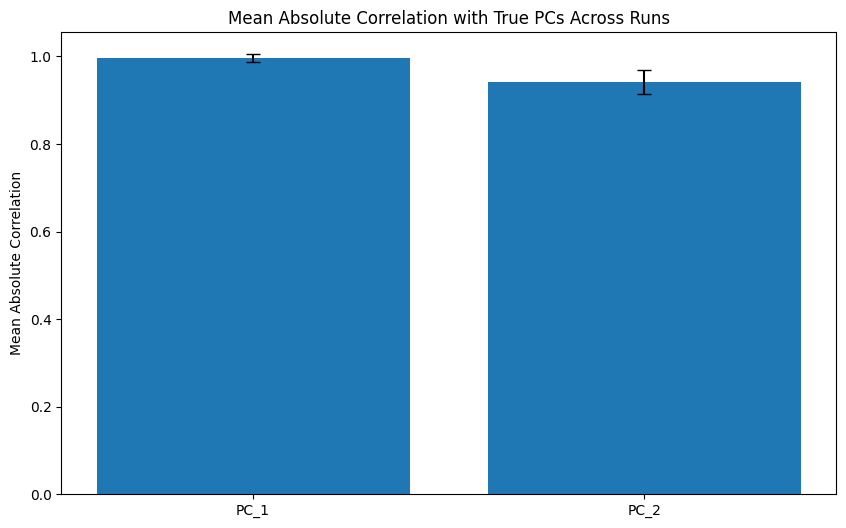

In [11]:
### Two phase training and testing

def two_phase_training_testing(model, data_before, data_after, m, model_paras_after, runs =10, graph = True):
    df_best_corr = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])
    for run in range(runs):
        print(f"run {run+1:2d}")
        print(f"X_before")
        order, similarity = Y_aligned_training_testing_online(model, data_before, graph=False)
        # update the model parameters
        for key, value in model_paras_after.items():
            if hasattr(model, key):
                setattr(model, key, value)
        print(f"X_after")
        order, similarity = Y_aligned_training_testing_online(model, data_after, graph=False)
        # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr.iloc[run, :] = ordered_similarity
        print(f"run {run+1:2d} | order = {order} | best|corr|= {np.round(similarity,3)}")

    if graph == True:
        # plot the bar graph with error bars of mean and std based on df_best_corr
        means = df_best_corr.mean(axis=0)
        stds = df_best_corr.std(axis=0)
        plt.figure(figsize=(10, 6))
        plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
        # plt.ylim(0, 1.1)
        plt.ylabel('Mean Absolute Correlation')
        plt.title('Mean Absolute Correlation with True PCs Across Runs')
        plt.show()
    

leen_model  = LeenCompletePCA(**model_paras)

two_phase_training_testing(leen_model, X_before, X_after, m, model_paras, runs = 10, graph = True)

leen_model.reset()